# 0. Install Packages and import dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
!pip install -q nltk
!pip install -q gensim
!pip install -q pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 1. Load and filter data

In [3]:
file_id = "1JV1042569xU3Gu0cUZOWdPjYuOp2KOlD"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

In [4]:
print(f"A total of {len(df)} articles are left")

A total of 806 articles are left


In [5]:
import numpy as np
import json
import glob

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

#spacy
import spacy
!python -m spacy download en_core_web_md
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
warnings.filterwarnings("ignore", category=DeprecationWarning)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 60.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


#2. NLP Preprocessing

## 2.1 Remove stopwords

In [6]:
stopwords_to_remove = set(stopwords.words("english"))
stopwords_to_remove.update(['however', 'creatine', 'supplementation'])
def remove_stopwords(text):
  tokens = nltk.word_tokenize(text.lower())
  filtered_tokens = [token for token in tokens if token not in stopwords_to_remove]
  return " ".join(filtered_tokens)

In [7]:
test_text = "Effect of creatine however supplementation on kidney function: a systematic review and meta-analysis. Creatine monohydrate is a widely used dietary supplement with proven benefits in athletic performance and potential therapeutic applications in clinical populations. However, concerns regarding its impact on renal function persist, largely due to elevated serum creatinine levels associated with creatine intake. A comprehensive literature search was conducted in PubMed, Scopus, Web of Science, and Google Scholar for studies published between January 2000 and March 2025. Primary outcomes were serum creatinine and glomerular filtration rate (GFR). Meta-analyses were performed using a random-effects model, with subgroup analysis by supplementation duration. Twenty-one studies were included in the systematic review, and 12 studies (177 participants in the creatine group and 263 in control) were eligible for meta-analysis of serum creatinine levels. Creatine supplementation was associated with a small but statistically significant increase in serum creatinine (MD: 0.07 µmol/L; 95% CI: 0.01 to 0.12; p = 0.03). Subgroup analysis of the creatinine outcome based on follow-up duration revealed that the intervention effect was significant in studies with a follow-up of ≤ 1 week (MD = 0.12; 95% CI: 0.03 to 0.21). However, no significant effect was observed in studies with a follow-up of 1 to 12 weeks (MD = 0.04; 95% CI: - 0.09 to 0.17). The effect became significant again in studies with a follow-up of more than 12 weeks. The meta-analysis revealed a non-statistically significant differences in GFR following creatine supplementation compared to control. Creatine supplementation is associated with a modest, transient increase in serum creatinine levels, likely due to metabolic turnover rather than renal impairment. No significant changes were observed in GFR, suggesting preserved kidney function. Not applicable."

In [12]:
''' tokens = nltk.word_tokenize(test_text.lower())
filtered_tokens = [token for token in tokens if token not in stopwords_to_remove]
print(" ".join(filtered_tokens)) '''

' tokens = nltk.word_tokenize(test_text.lower())\nfiltered_tokens = [token for token in tokens if token not in stopwords_to_remove]\nprint(" ".join(filtered_tokens)) '

In [8]:
lemmatizer = spacy.load('en_core_web_sm', disable=["parser", "ner"]) #Disable ner and parser to make the model run faster
allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']
def lemmatize(text):
  text_lemma_list = [token.lemma_ for token in lemmatizer(text) if token.pos_ in allowed_postags]
  return " ".join(text_lemma_list)

#Tokenize and remove small tokens and punctuation
def gensim_words(text):
  gensim_word = gensim.utils.simple_preprocess(text, deacc=True, min_len=3)
  return gensim_word

In [9]:
#Apply all pipeline processes
def nlp_preprocessing_pipeline(text):
  return gensim_words(remove_stopwords(lemmatize(text)))
  #return gensim_words(lemmatize(text))


In [10]:
df["pre_proccessed_text"] = df["raw_corpus"].apply(nlp_preprocessing_pipeline)

In [11]:
#BIGRAMS AND TRIGRAMS
# Source: https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/#9createbigramandtrigrammodels

bigram_phrases = gensim.models.Phrases(df["pre_proccessed_text"], min_count=5, threshold=15) #threshold number of phrrases that are going to be found
trigram_phrases = gensim.models.Phrases(bigram_phrases[df["pre_proccessed_text"]], threshold=15)

bigram = gensim.models.phrases.Phraser(bigram_phrases)
trigram = gensim.models.phrases.Phraser(trigram_phrases)

def make_trigram(text):
  return trigram[bigram[text]]

df["trigram_text"] = df["pre_proccessed_text"].apply(make_trigram)

In [12]:
''' for phrase, score in bigram.phrasegrams.items():
    print(phrase, score) '''

' for phrase, score in bigram.phrasegrams.items():\n    print(phrase, score) '

In [13]:
apply_bigrams_and_trigrams = False
if apply_bigrams_and_trigrams:
  data = df["trigram_text"]
else:
  data = df["pre_proccessed_text"]

In [14]:
#TF-IDF REMOVAL

# Adapted from: https://github.com/wjbmattingly/topic_modeling_textbook/blob/main/03_03_lda_model_demo_bigrams_trigrams.ipynb
from gensim.models import TfidfModel

APPLY_TFIDF = True

id2word = corpora.Dictionary(data)
corpus = list(data.apply(lambda doc:  id2word.doc2bow(doc)))#convert to bag of words

def apply_tfidf(corpus, id2word):
  tfidf = TfidfModel(corpus, id2word=id2word)  #model that contains document frequency
  low_value = 0.01
  words = []
  words_missing_in_tfidf = []
  for doc_index in range(0, len(corpus)):
    bag_of_words_doc = corpus[doc_index]
    low_value_words = []
    tfidf_ids = [id for id, value in tfidf[bag_of_words_doc]] #Get index of words in document in tf_idf model
    bow_ids = [id for id, value in bag_of_words_doc] #Get index of words in document
    low_value_words = [id for id, value in tfidf[bag_of_words_doc] if value < low_value] #remove low value words from document
    drops = low_value_words + words_missing_in_tfidf #words to drop
    for item in drops:
      words.append(id2word[item])

    words_missing_in_tfidf = [id for id in bow_ids if id not in tfidf_ids] #words missing in tfidf due to low value

    new_bow = [b for b in bag_of_words_doc if b[0] not in low_value_words and b[0] not in words_missing_in_tfidf] #new bag of words wih filtered words
    corpus[doc_index] = new_bow

  #rebuild dictionary in case words were removed.
  filtered_texts = [[id2word[id] for id, count in doc] for doc in corpus]
  new_id2word = corpora.Dictionary(filtered_texts)
  new_corpus = [new_id2word.doc2bow(doc) for doc in filtered_texts]

  print(f"Words removed: {set(words)}")
  return new_corpus, new_id2word

if APPLY_TFIDF:
  corpus, id2word = apply_tfidf(corpus, id2word)

df["bow_format"] = corpus

Words removed: {'measure', 'level', 'treat', 'improve', 'long', 'include', 'significantly', 'suggest', 'investigate', 'provide', 'associate', 'use', 'aim', 'sample', 'factor', 'show', 'acid', 'body', 'week', 'intervention', 'water', 'compare', 'randomly', 'outcome', 'receive', 'double', 'performance', 'combine', 'relate', 'short', 'assign', 'placebo', 'trial', 'metabolism', 'remain', 'perform', 'datum', 'influence', 'plasma', 'day', 'effect', 'study', 'randomize', 'increase', 'result', 'follow', 'group', 'benefit', 'subject', 'respectively', 'significant', 'muscle', 'time'}


Coherence evaluation

#Train Model

In [15]:
!wget http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip

--2025-12-24 12:47:38--  http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
Resolving mallet.cs.umass.edu (mallet.cs.umass.edu)... 128.119.246.70
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://mallet.cs.umass.edu/dist/mallet-2.0.8.zip [following]
--2025-12-24 12:47:39--  https://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16184794 (15M) [application/zip]
Saving to: ‘mallet-2.0.8.zip’

mallet-2.0.8.zip    100%[===================>]  15.43M  69.5MB/s    in 0.2s    

2025-12-24 12:47:39 (69.5 MB/s) - ‘mallet-2.0.8.zip’ saved [16184794/16184794]



In [16]:
!unzip mallet-2.0.8.zip

Archive:  mallet-2.0.8.zip
   creating: mallet-2.0.8/
   creating: mallet-2.0.8/bin/
  inflating: mallet-2.0.8/bin/classifier2info  
  inflating: mallet-2.0.8/bin/csv2classify  
  inflating: mallet-2.0.8/bin/csv2vectors  
  inflating: mallet-2.0.8/bin/mallet  
  inflating: mallet-2.0.8/bin/mallet.bat  
  inflating: mallet-2.0.8/bin/mallethon  
  inflating: mallet-2.0.8/bin/prepend-license.sh  
  inflating: mallet-2.0.8/bin/svmlight2vectors  
  inflating: mallet-2.0.8/bin/text2classify  
  inflating: mallet-2.0.8/bin/text2vectors  
  inflating: mallet-2.0.8/bin/vectors2classify  
  inflating: mallet-2.0.8/bin/vectors2info  
  inflating: mallet-2.0.8/bin/vectors2topics  
  inflating: mallet-2.0.8/bin/vectors2vectors  
  inflating: mallet-2.0.8/build.xml  
   creating: mallet-2.0.8/class/
   creating: mallet-2.0.8/class/cc/
   creating: mallet-2.0.8/class/cc/mallet/
   creating: mallet-2.0.8/class/cc/mallet/classify/
  inflating: mallet-2.0.8/class/cc/mallet/classify/AdaBoost.class  
  in

In [17]:
mallet_path = "/content/mallet-2.0.8/bin/mallet"

In [18]:
!pip install little_mallet_wrapper
import little_mallet_wrapper as lmw

In [19]:
!mkdir model_output

In [20]:
#training_data = [" ".join([id2word[id] for id, freq in corpus_item for _ in range(freq)]) for corpus_item in corpus]
SKIP_TRAINING = False
num_topics_selected = 19
training_data = [" ".join(data_item) for data_item in data]
if not SKIP_TRAINING:
  topic_keys, topic_distributions = lmw.quick_train_topic_model(mallet_path,
                                                                '/content/model_output',
                                                                num_topics_selected,
                                                                training_data)


Importing data...
Complete
Training topic model...
Complete


In [26]:
#Uncomment if trainig model
#!zip -r /content/model_output.zip ./model_outputA

In [23]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

dictionary = Dictionary(data)
SKIP_EXPLORATION = True
iterations = 10
if not SKIP_EXPLORATION:
  for topic in range(7, 20):
    scores = []
    for iteration in range(iterations):
      topic_keys, topic_distributions = lmw.quick_train_topic_model(mallet_path,
                                                              '/content',
                                                              topic,
                                                              training_data)

      coherence_model = CoherenceModel(
            topics=topic_keys,
            texts=data,
            dictionary=dictionary,
            coherence='c_v'
        )
      coherence = coherence_model.get_coherence()  # get coherence value
      scores.append(coherence)

    print(f"Average coherence score for {topic} topics: {sum(scores)/len(scores)}")


# Visualize and evaluate model

In [141]:
token_average = sum([len(doc) for doc in data])/len(data)
print(f"Average number of tokens per document: {token_average}")

Average number of tokens per document: 118.36848635235732


In [39]:
#Load final model
file_id = "196XG5XhWYg5t24syn_18Mu-Gt4OcNFNf"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
output_zip = "model_output.zip"
!wget -O {output_zip} "{url}"
!unzip model_output.zip

--2025-12-24 14:12:10--  https://drive.google.com/uc?export=download&id=196XG5XhWYg5t24syn_18Mu-Gt4OcNFNf
Resolving drive.google.com (drive.google.com)... 172.253.63.139, 172.253.63.113, 172.253.63.101, ...
Connecting to drive.google.com (drive.google.com)|172.253.63.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=196XG5XhWYg5t24syn_18Mu-Gt4OcNFNf&export=download [following]
--2025-12-24 14:12:10--  https://drive.usercontent.google.com/download?id=196XG5XhWYg5t24syn_18Mu-Gt4OcNFNf&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.31.132, 2607:f8b0:4004:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.31.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1149751 (1.1M) [application/octet-stream]
Saving to: ‘model_output.zip’

model_output.zip    100%[===================>]   1.10M  --.-KB

In [40]:
topic_keys_path = f"/content/model_output/mallet.topic_keys.{num_topics_selected}"
topic_distributions_path = f"/content/model_output/mallet.topic_distributions.{num_topics_selected}"
topic_keys = lmw.load_topic_keys(topic_keys_path)
topic_distributions = lmw.load_topic_distributions(topic_distributions_path)

In [41]:
coherence_model = CoherenceModel(
            topics=topic_keys,
            texts=data,
            dictionary=dictionary,
            coherence='c_v'
        )
cv_score = coherence_model.get_coherence()
print("c_v coherence:", cv_score)

c_v coherence: 0.46843915802534863


In [42]:
coherence_model.get_coherence_per_topic()

[np.float64(0.5807986598288657),
 np.float64(0.6687974627547772),
 np.float64(0.45532506818689883),
 np.float64(0.42699921462603907),
 np.float64(0.35548414583316634),
 np.float64(0.37787862182595455),
 np.float64(0.42729239942345904),
 np.float64(0.5450585683680329),
 np.float64(0.3410265781542882),
 np.float64(0.3990255565372053),
 np.float64(0.35915749615682746),
 np.float64(0.6118138229961855),
 np.float64(0.6000377755420414),
 np.float64(0.4794738603458993),
 np.float64(0.44897079166963605),
 np.float64(0.7550321376583117),
 np.float64(0.35353718196012107),
 np.float64(0.32470552495497346),
 np.float64(0.3899291356589413)]

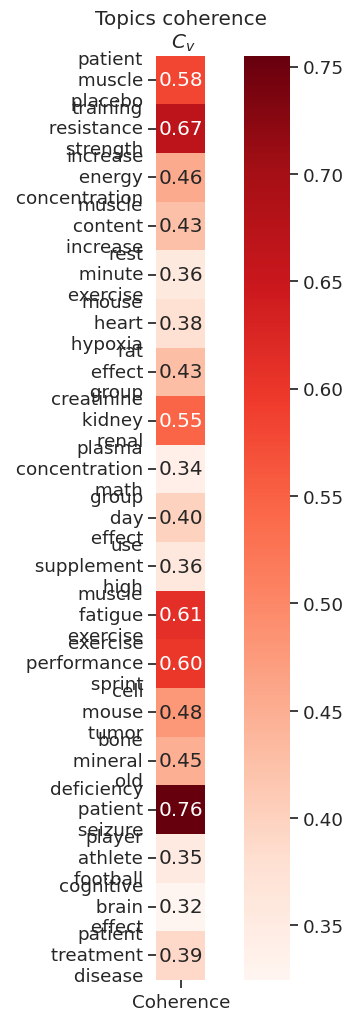

In [32]:
import seaborn as sns
topics_str = [ '\n '.join(t[:3]) for t in topic_keys ]
data_topic_score = pd.DataFrame( data=zip(topics_str, coherence_model.get_coherence_per_topic()), columns=['Topic', 'Coherence'] )
data_topic_score = data_topic_score.set_index('Topic')

fig, ax = plt.subplots( figsize=(10,12) )
ax.set_title("Topics coherence\n $C_v$")
sns.heatmap(data=data_topic_score, annot=True, square=True,
            cmap='Reds', fmt='.2f',
            linecolor='black', ax=ax )
plt.yticks( rotation=0 )
ax.set_xlabel('')
ax.set_ylabel('')
fig.show()

In [33]:
lmw.get_top_docs(training_data, topic_distributions, 7, n=3)

[(0.7221255352191588,
  'effect kidney stone recurrence athlete case report several study examine effect monohydrate renal function previous study investigate effect kidney stone human renal ultrasound healthy young athlete know renal morphological normal kidney function normal phospholipid uric acid reveal kidney stone low right calyx extracorporeal shock wave lithotripsy apply order break stone twentyone day later follow renal ultrasound show absence stone kidney week later athlete start monohydrate month month stop monohydrate third renal ultrasound confirm absence stone kidney month monohydrate athlete history kidney stone associate kidney stone recurrence long run'),
 (0.7163585135520055,
  'affect kidney function animal model pre existing renal failure widely use ergogenic substance athlete safety prolonged intake question base case report animal datum investigate effect prolong ingestion renal function animal normal kidney function pre existing kidney failure respectively rat ra

In [34]:
len(topic_distributions)

806

In [43]:
for i, t in enumerate(topic_keys):
    print(i, '\t', ' '.join(t[:20]))

0 	 patient muscle placebo function trial week strength control effect blind improve study double outcome functional randomize assess quality physical life
1 	 training resistance strength body group mass muscle week increase repetition press composition fat effect leg exercise placebo train performance endurance
2 	 increase energy concentration level brain phosphocreatine suggest high activity human result phosphate decrease metabolism oral uptake ratio show use lead
3 	 muscle content increase skeletal fiber glucose protein diet expression glycogen total effect beta feed insulin study type control rat dietary
4 	 rest minute exercise swimmer swimming pressure postexercise compartment temperature swim heat male body bout leg response hormone blood anterior complex
5 	 mouse heart hypoxia fetal birth cardiac asphyxia injury function reduce maternal ischemia brain treatment pregnancy cerebral acute term cord protect
6 	 rat effect group stress oxidative induce exercise diet activity an

In [49]:
#Collect topic info for plotting
df_analyze = df

doc_topic_matrix = np.zeros((len(df_analyze), num_topics_selected))


for doc_index, dist in enumerate(topic_distributions):
      doc_topic_matrix[doc_index, :] = dist

for topic_id in range(num_topics_selected):
    df_analyze[f"topic_{topic_id + 1}"] = doc_topic_matrix[:, topic_id]

topic_columns = [col for col in df_analyze.columns if col.startswith("topic_")]

In [50]:
# Create 5 year bins
bins = list(range(df['year'].max(), df['year'].min() -1, -5))
bins.sort()
bins[0] = 1984
labels = [f"{bins[i] + 1}-{bins[i+1]}" for i in range(len(bins)-1)]
df_analyze['year_bin'] = pd.cut(df_analyze['year'], bins=bins, labels=labels, right=True)

df_topic_sum_by_bin = df_analyze.groupby('year_bin')[topic_columns].sum()
df_topic_sum_by_bin = df_topic_sum_by_bin.reset_index()

/tmp/ipython-input-3517333680.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_topic_sum_by_bin = df_analyze.groupby('year_bin')[topic_columns].sum()


In [29]:
bins

[1984, 1991, 1996, 2001, 2006, 2011, 2016, 2021, 2026]

In [51]:
df_topic_sum_by_bin

,year_bin,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19
0,1985-1991,0.001067,0.001879,0.138057,0.050603,0.000463,0.000558,0.001389,0.038017,0.000340,0.032079,0.001831,0.000813,0.026932,0.000875,0.000274,0.234761,0.000422,0.000471,0.469169
1,1992-1996,0.107729,0.300452,2.682114,2.658892,0.382964,0.327582,0.435288,0.539834,0.163497,5.675127,0.198140,1.137519,8.577567,0.043905,0.036176,0.050099,0.100217,0.265822,0.317077
2,1997-2001,1.179056,10.100802,10.388375,7.172513,3.847982,1.349912,2.099756,4.885463,0.588108,31.773383,7.954635,8.077797,22.607147,0.717328,0.287916,2.959238,1.725454,0.155215,5.129917
3,2002-2006,7.218191,11.866948,15.543194,15.770309,4.648481,3.237114,6.788341,7.637615,1.526489,44.260267,6.023479,4.533458,20.916310,6.907438,0.672581,3.171448,4.632911,1.586687,7.058738
4,2007-2011,5.236297,11.219942,8.856016,7.548556,1.916137,2.800004,9.065166,4.942733,3.194255,25.996822,4.083321,4.220796,9.830133,4.517348,0.711040,3.341301,1.522005,3.551220,3.446907
5,2012-2016,5.990375,14.045607,7.236147,4.394476,0.719507,6.846875,14.315666,4.974235,4.276445,23.545720,4.423650,2.174002,8.126605,4.566962,2.320038,4.643255,1.443068,3.543295,2.414072
6,2017-2021,8.175621,11.882725,8.056437,5.611783,0.620362,4.006923,6.789759,3.821531,5.170294,22.650036,7.504596,4.146311,4.721174,6.459611,2.154609,3.048674,1.043479,5.446708,4.689368
7,2022-2026,9.424003,10.521237,8.161422,3.008098,1.191919,4.488443,7.837302,3.363542,2.759572,20.403793,13.391284,1.768943,5.245746,15.326971,2.430673,10.349015,2.086586,6.147613,4.093839


In [52]:
cluster_to_topics = {
    "Clinical trials and supplementation terms": [1, 10, 11],
    "Exercise performance and sports science": [2, 5, 12, 13, 17],
    "Bioenergetics and metabolic mechanisms": [3, 4, 9],
    "Neurological and neurodevelopmental research": [6, 16, 18, 19],
    "Animal and cellular disease models": [7, 14],
    "Renal effects and creatinine metabolism": [8],
    "Musculoskeletal health and aging": [15]
}

In [53]:
df_topic_sum_by_bin['total'] =  df_topic_sum_by_bin[topic_columns].sum(axis=1)
df_topic_sum_by_bin[topic_columns] = df_topic_sum_by_bin[topic_columns].div(df_topic_sum_by_bin["total"], axis=0)

In [54]:
df_topic_sum_by_bin['total2'] =  df_topic_sum_by_bin[topic_columns].sum(axis=1)
df_topic_sum_by_bin.drop(['total2'], axis=1, inplace=True)

In [55]:
for cluster, topics in cluster_to_topics.items():
    cols = [f"topic_{t}" for t in topics]
    df_topic_sum_by_bin[cluster] = df_topic_sum_by_bin[cols].sum(axis=1)

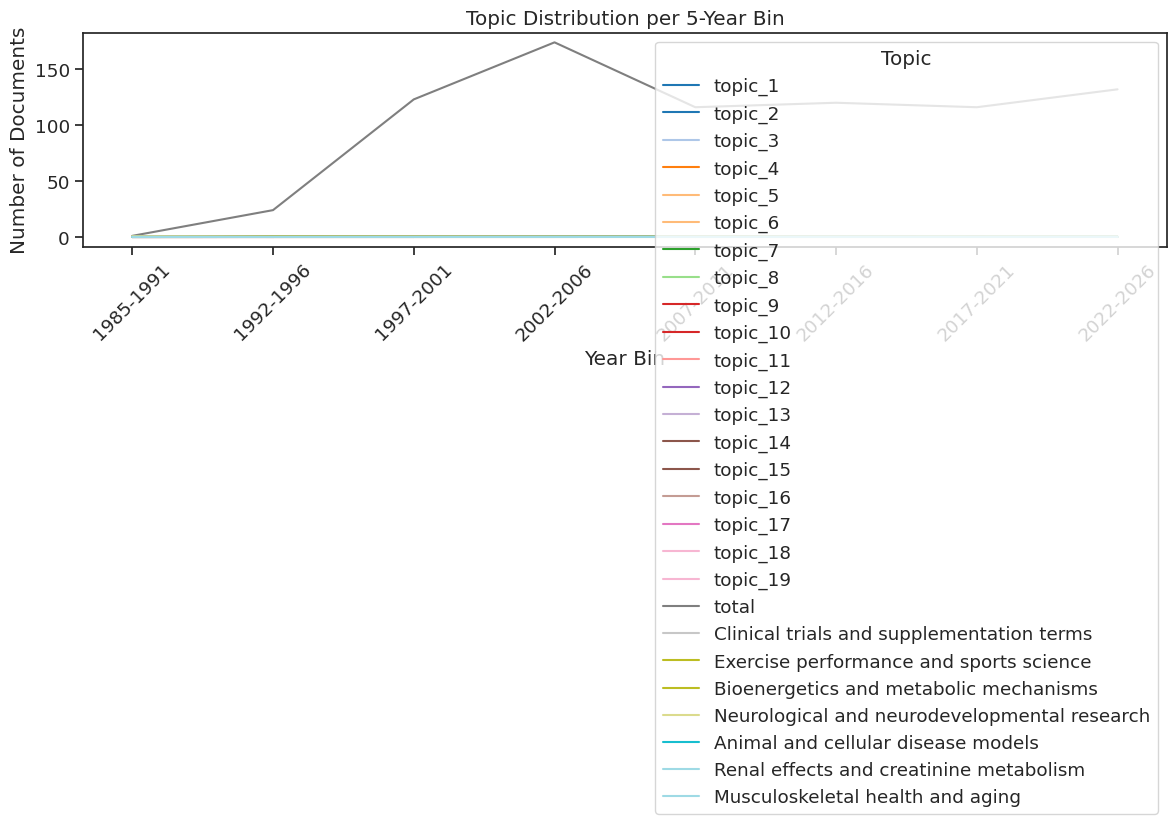

In [56]:
import matplotlib.pyplot as plt

#df_topic_sum_by_bin.drop(topic_columns, axis=1, inplace=True)
df_topic_sum_by_bin.plot(x="year_bin", figsize=(12,6), colormap='tab20')
#df_topic_sum_by_bin.plot(x="year_bin", y=["topic_13"], figsize=(12,6), colormap='tab20')

plt.xlabel('Year Bin')
plt.ylabel('Number of Documents')
plt.title('Topic Distribution per 5-Year Bin')
plt.legend(title='Topic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
topic_id_to_name = {
    1: "Clinical trials terms",
    2: "Resistance training and body composition",
    3: "Brain energy metabolism and phosphocreatine dynamics",
    4: "Skeletal muscle metabolism and insulin–glycogen regulation",
    5: "Swimming performance",
    6: "Perinatal hypoxia and cardio-neuroprotection",
    7: "Oxidative stress and antioxidant effects in animals",
    8: "Renal function and creatinine excretion",
    9: "Amino acid metabolism and methylation pathways",
    10: "Clinical trial terms",
    11: "General research terms",
    12: "Muscle fatigue, force production, and recovery",
    13: "High-intensity and anaerobic exercise performance",
    14: "Cellular and molecular effects in disease models",
    15: "Bone health and mineral density in aging populations",
    16: "Creatine deficiency syndromes and neurological disorders",
    17: "Elite sports performance and injury risk",
    18: "Cognitive performance and sleep deprivation effects",
    19: "Mitochondrial dysfunction and neuroprotective effects"
}

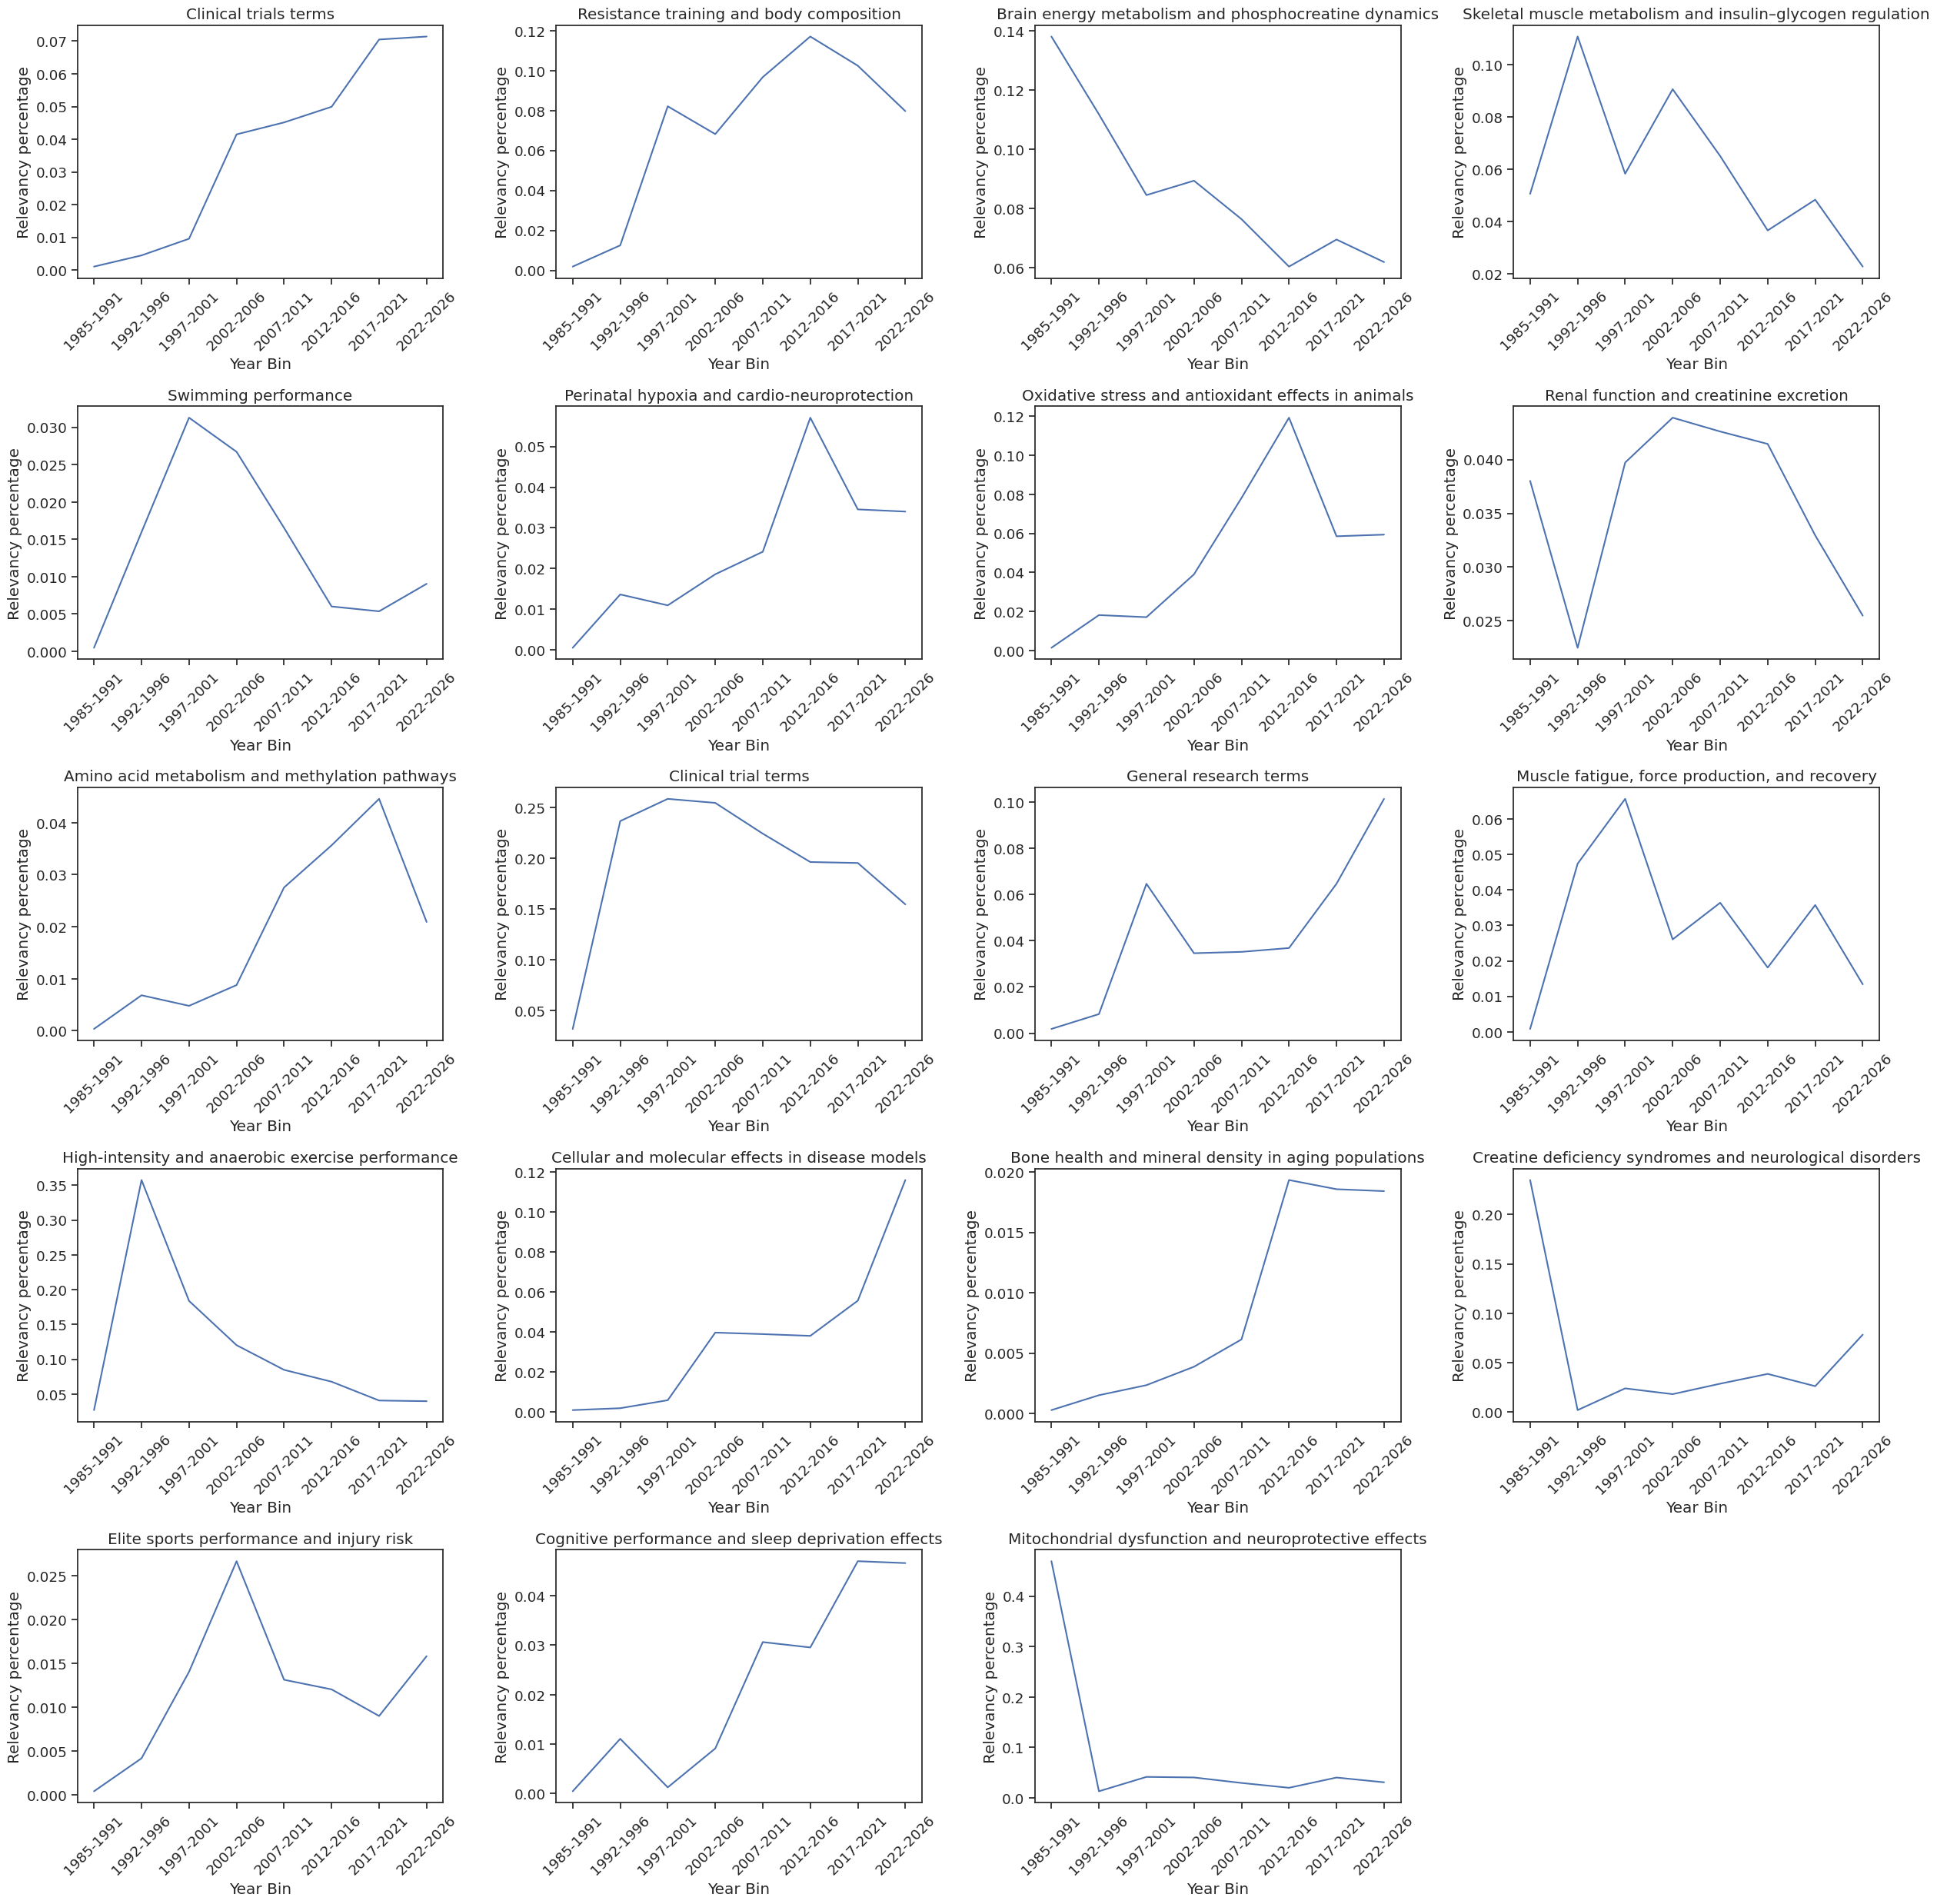

In [60]:
import matplotlib.pyplot as plt
import math

topics = num_topics_selected

n_rows = math.ceil(num_topics_selected / 4)

fig, axes = plt.subplots(n_rows, 4, figsize=(25, 5 * n_rows))
axes = axes.flatten()  # flatten to easily index

for i in range(topics):
    ax = axes[i]

    ax.plot(df_topic_sum_by_bin["year_bin"], df_topic_sum_by_bin[f"topic_{i+1}"])

    ax.set_title(f"{topic_id_to_name[i + 1]}")
    ax.set_xlabel("Year Bin")
    ax.set_ylabel("Relevancy percentage")
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


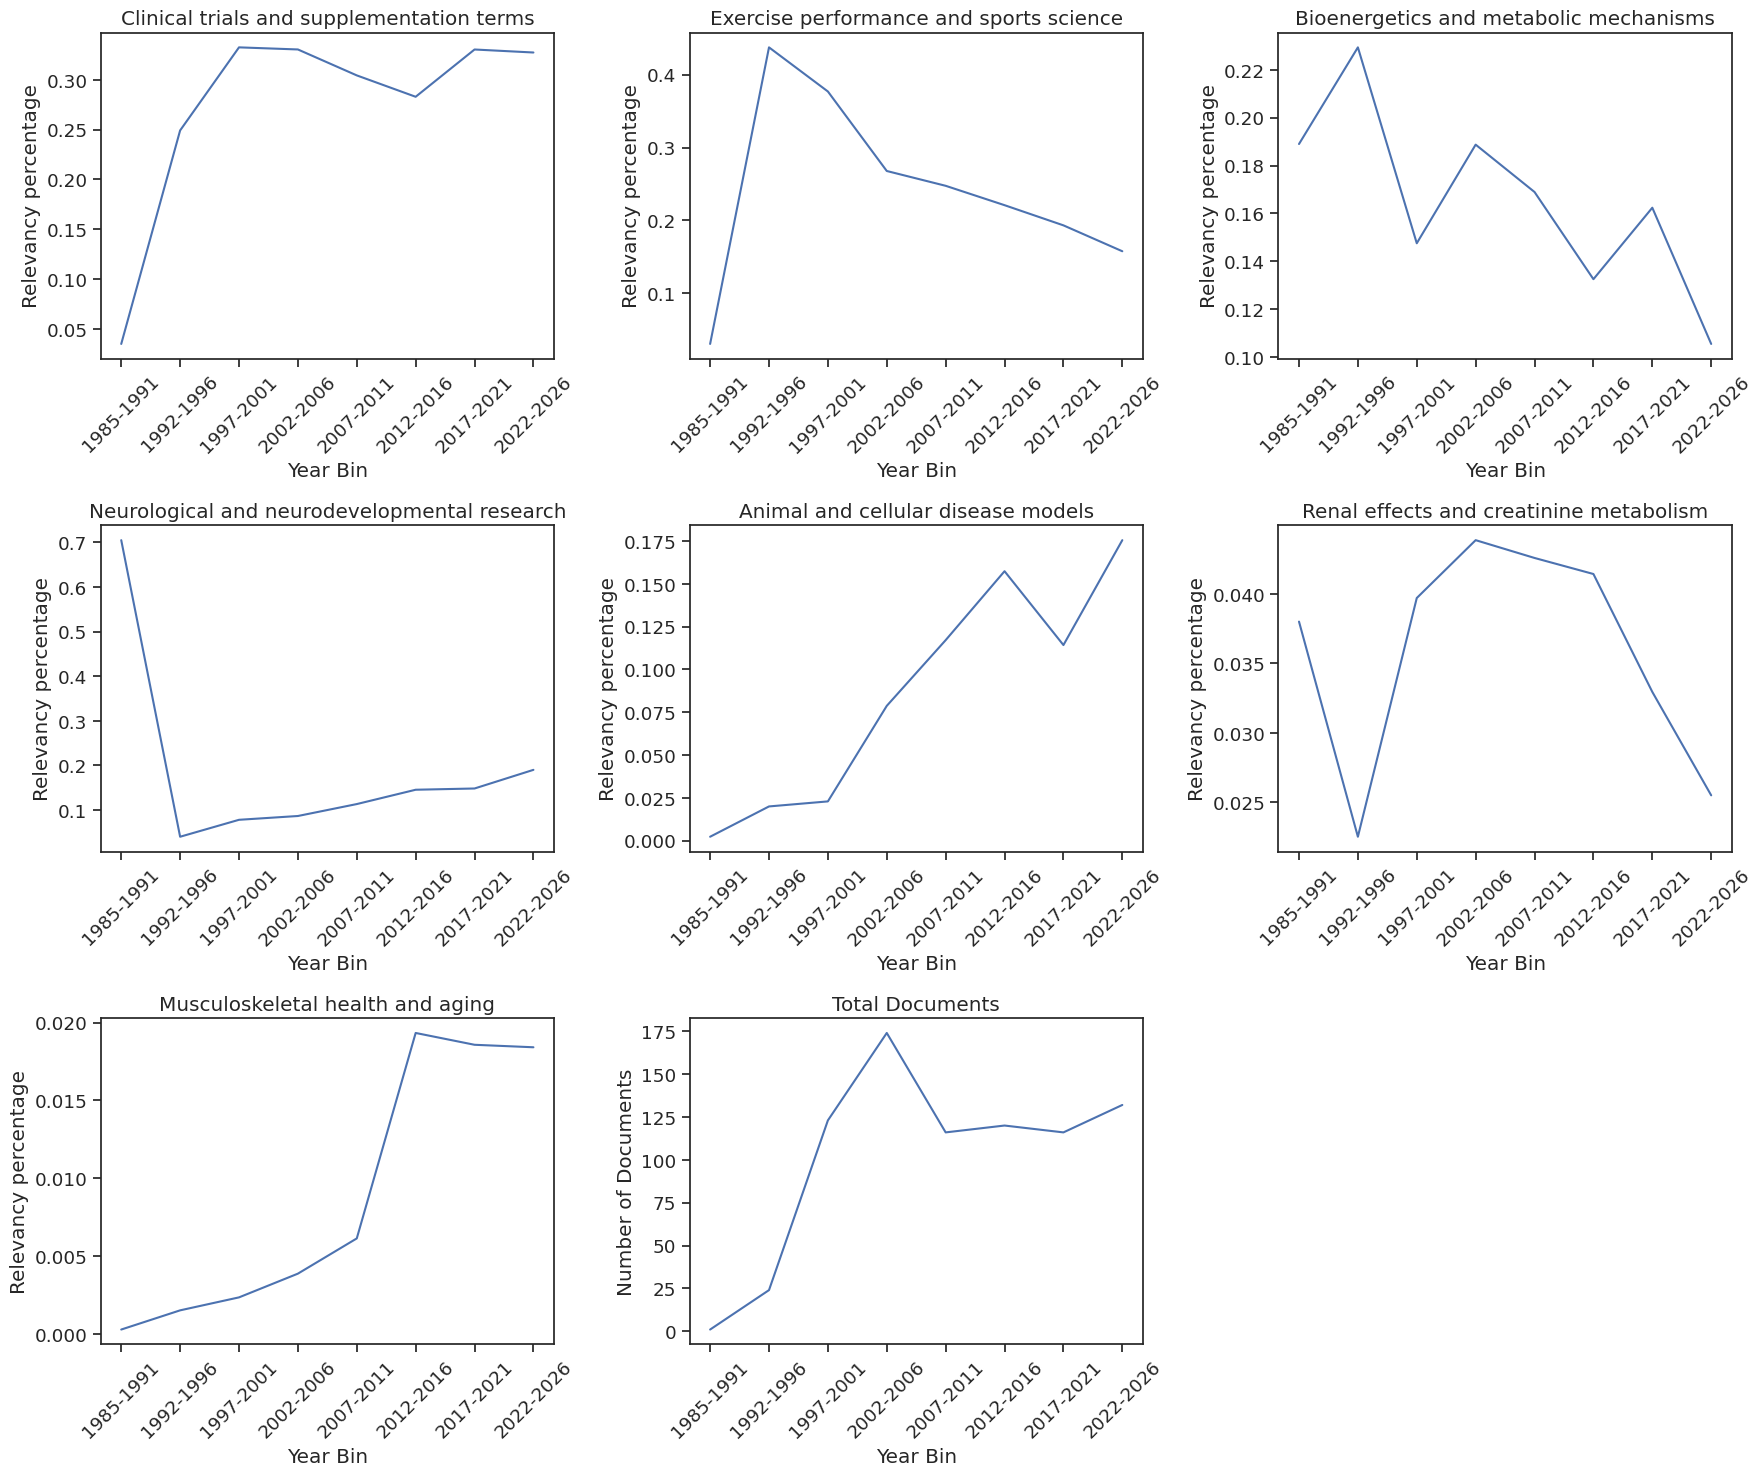

In [120]:
clusters = len(cluster_to_topics)
n_rows = math.ceil(clusters / 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cluster_name in enumerate(list(cluster_to_topics.keys())):
    ax = axes[i]

    ax.plot(df_topic_sum_by_bin["year_bin"], df_topic_sum_by_bin[cluster_name])

    ax.set_title(cluster_name)
    ax.set_xlabel("Year Bin")
    ax.set_ylabel("Relevancy percentage")
    ax.tick_params(axis="x", rotation=45)

ax = axes[i + 1]

ax.plot(df_topic_sum_by_bin["year_bin"], df_topic_sum_by_bin['total'])

ax.set_title('Total Documents')
ax.set_xlabel("Year Bin")
ax.set_ylabel("Number of Documents")
ax.tick_params(axis="x", rotation=45)

for j in range(i + 2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()